# Лабораторная работа №3: Решение систем нелинейных уравнений
## Студент: Сергиенко Александр Сергеевич
### Группы: ФИТ-231

### Вариант: 3. y′ = y − x^2, y(0) = 1, x ∈ [0, 1]

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Определение функции f(x, y) из уравнения y' = f(x, y)
def f(x, y):
    return y - x**2

# Точное решение для проверки
def exact_solution(x):
    return x**2 + 2*x + 2 - np.exp(x)

# Параметры задачи
x0, y0 = 0, 1
x_end = 1
eps = 1e-4
h = 0.1 # Начальный шаг

def get_nodes(x0, x_end, h):
    return np.arange(x0, x_end + h/2, h)

## 1. Найдите решение задачи Коши для ОДУ первого порядка с точностью eps тремя численными методами:

### Модифицированный метод Эйлера (Метод Эйлера-Коши)

In [ ]:
def modified_euler(x0, y0, x_end, h):
    x_pts = get_nodes(x0, x_end, h)
    y_pts = [y0]
    
    for i in range(len(x_pts) - 1):
        x_n, y_n = x_pts[i], y_pts[i]
        # Прогноз
        y_predict = y_n + h * f(x_n, y_n)
        # Коррекция
        y_next = y_n + (h/2) * (f(x_n, y_n) + f(x_pts[i+1], y_predict)) # неявный
        y_pts.append(y_next)
        
    return x_pts, np.array(y_pts)

### Метод Рунге-Кутта 4-го порядка

In [ ]:
def runge_kutta_4(x0, y0, x_end, h):
    x_pts = get_nodes(x0, x_end, h)
    y_pts = [y0]
    
    for i in range(len(x_pts) - 1):
        x_n, y_n = x_pts[i], y_pts[i]
        
        k1 = h * f(x_n, y_n)
        k2 = h * f(x_n + h/2, y_n + k1/2)
        k3 = h * f(x_n + h/2, y_n + k2/2)
        k4 = h * f(x_n + h, y_n + k3)
        
        y_next = y_n + (k1 + 2*k2 + 2*k3 + k4) / 6 #явный
        y_pts.append(y_next)
        
    return x_pts, np.array(y_pts)

### Метод Адамса (4-шаговый метод прогноз-коррекция)

In [ ]:
# Адамс (AB4-AM4, прогноз-коррекция): многошаговый 4-шаговый неявный метод.
# неявный

def adams_method(x0, y0, x_end, h):
    # Для метода Адамса нужны 4 начальные точки, берем их из Рунге-Кутта
    x_rk, y_rk = runge_kutta_4(x0, y0, x0 + 3*h, h)
    x_pts = list(get_nodes(x0, x_end, h))
    y_pts = list(y_rk)
    
    # Предвычисляем значения f в узлах
    fs = [f(x_pts[i], y_pts[i]) for i in range(4)]
    
    for i in range(3, len(x_pts) - 1):
        # Экстраполяционный метод Адамса-Башфорта (прогноз)
        y_pred = y_pts[i] + h/24 * (55*fs[i] - 59*fs[i-1] + 37*fs[i-2] - 9*fs[i-3])
        
        # Значение f в прогнозируемой точке
        f_next_pred = f(x_pts[i+1], y_pred)
        
        # Интерполяционный метод Адамса-Мултона (коррекция)
        y_corr = y_pts[i] + h/24 * (9*f_next_pred + 19*fs[i] - 5*fs[i-1] + fs[i-2])
        
        y_pts.append(y_corr)
        fs.append(f(x_pts[i+1], y_corr))
        
    return np.array(x_pts), np.array(y_pts)

## Результаты и анализ

,x,Точное решение,Мод. Эйлер,Погрешность Мод. Эйлер,Рунге-Кутта 4,Погрешность Рунге-Кутта 4,Адамс,Погрешность Адамс
0,0.0,1.000000,1.000000,0.000000,1.000000,0.000000e+00,1.000000,0.000000e+00
1,0.1,1.104829,1.104500,0.000329,1.104829,1.235910e-07,1.104829,1.235910e-07
2,0.2,1.218597,1.217923,0.000675,1.218597,2.512678e-07,1.218597,2.512678e-07
3,0.3,1.340141,1.339104,0.001037,1.340141,3.825227e-07,1.340141,3.825227e-07
4,0.4,1.468175,1.466760,0.001415,1.468175,5.166961e-07,1.468175,6.114525e-07
5,0.5,1.601279,1.599470,0.001809,1.601278,6.529501e-07,1.601278,8.859123e-07
6,0.6,1.737881,1.735665,0.002217,1.737880,7.902383e-07,1.737880,1.210772e-06
7,0.7,1.876247,1.873609,0.002638,1.876246,9.272710e-07,1.876246,1.594233e-06
8,0.8,2.014459,2.011388,0.003071,2.014458,1.062476e-06,2.014457,2.044967e-06
9,0.9,2.150397,2.146884,0.003513,2.150396,1.193954e-06,2.150394,2.572875e-06


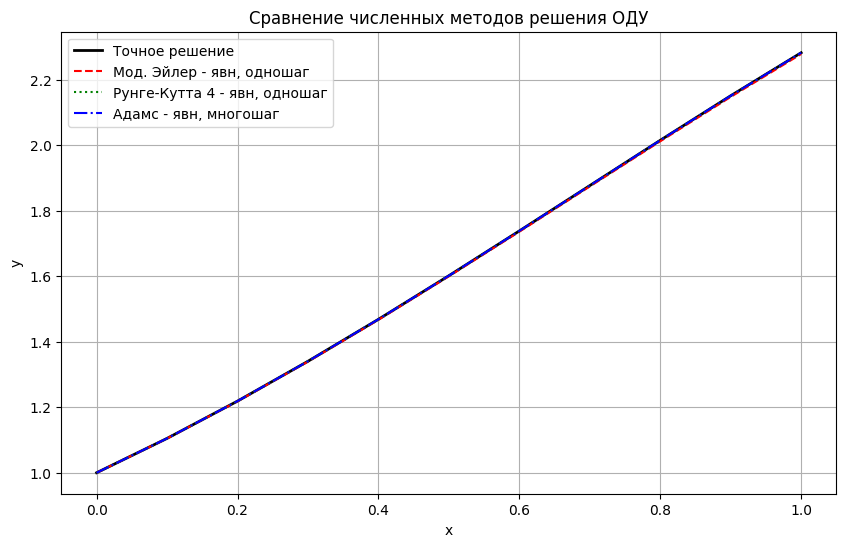

In [30]:
# Вычисление решений
x_vals = get_nodes(x0, x_end, h)
y_exact = exact_solution(x_vals)

_, y_euler = modified_euler(x0, y0, x_end, h)
_, y_rk = runge_kutta_4(x0, y0, x_end, h)
_, y_adams = adams_method(x0, y0, x_end, h)

# Сводная таблица
methods = {
    'Мод. Эйлер': y_euler,
    'Рунге-Кутта 4': y_rk,
    'Адамс': y_adams
}

data = {
    'x': x_vals,
    'Точное решение': y_exact
}

for method_name, y_method in methods.items():
    data[method_name] = y_method
    data[f'Погрешность {method_name}'] = np.abs(y_exact - y_method)

df = pd.DataFrame(data)
display(df)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_exact, 'k-', label='Точное решение', linewidth=2)
plt.plot(x_vals, y_euler, 'r--', label='Мод. Эйлер - явн, одношаг')
plt.plot(x_vals, y_rk, 'g:', label='Рунге-Кутта 4 - явн, одношаг')
plt.plot(x_vals, y_adams, 'b-.', label='Адамс - явн, многошаг')
plt.legend()
plt.grid(True)
plt.title("Сравнение численных методов решения ОДУ")
plt.xlabel("x")
plt.ylabel("y")
plt.show()